In [1]:
import setup
from importlib import reload
reload(setup)
from setup import *
Ag_comp = 0.5

# BF

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.41,15
,3000,0,0.10,63
,3000,0,0.43,15
,3000,0,0.42,31


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -854.78    58.04
p_loo      361.94        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1475   99.9%
   (0.70, 1]   (bad)         1    0.1%
   (1, Inf)   (very bad)    0    0.0%



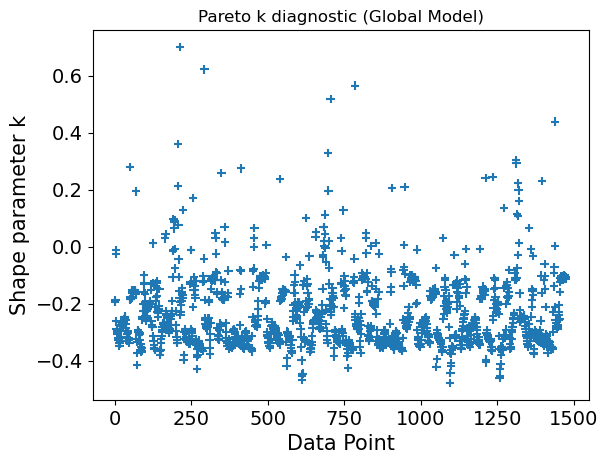

In [2]:
with pm.Model() as BF:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH# -> COOH* + # (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    rate = observables(log_rate) 

trace_BF, loo_BF = fit_and_evaluate(BF)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.087  0.038  -0.113   -0.014      0.019    0.011       7.0      31.0   1.53
deltaG4_0   0.093  0.105  -0.098    0.165      0.052    0.030       7.0      31.0   1.53
deltaG5_0  -0.055  0.195  -0.174    0.311      0.096    0.057       7.0      37.0   1.53
Gact2_0     0.614  0.163   0.304    0.709      0.080    0.047       7.0      37.0   1.53
sigma_rel   0.715  0.421   0.437    1.485      0.209    0.121       7.0      32.0   1.53
sigma_base  0.019  0.010   0.000    0.032      0.004    0.002       7.0      32.0   1.53
exponent    1.772  0.640   0.638    2.282      0.316    0.180       7.0      31.0   1.53


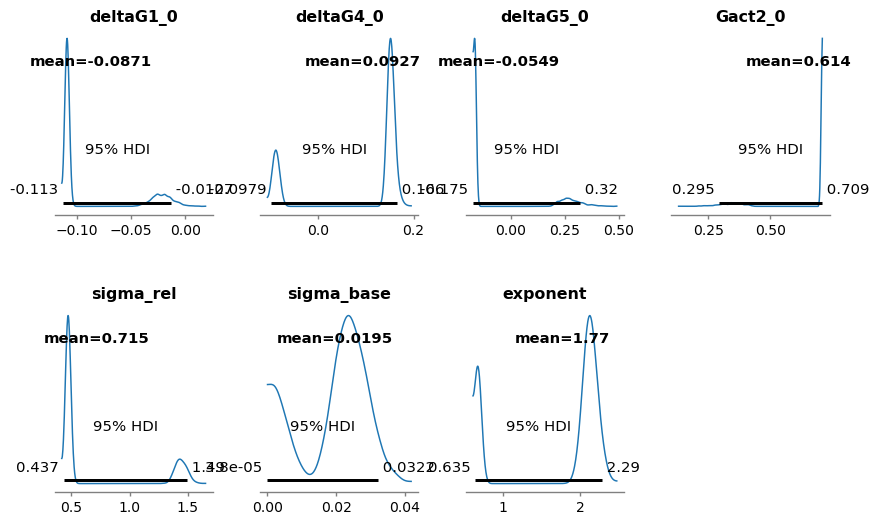

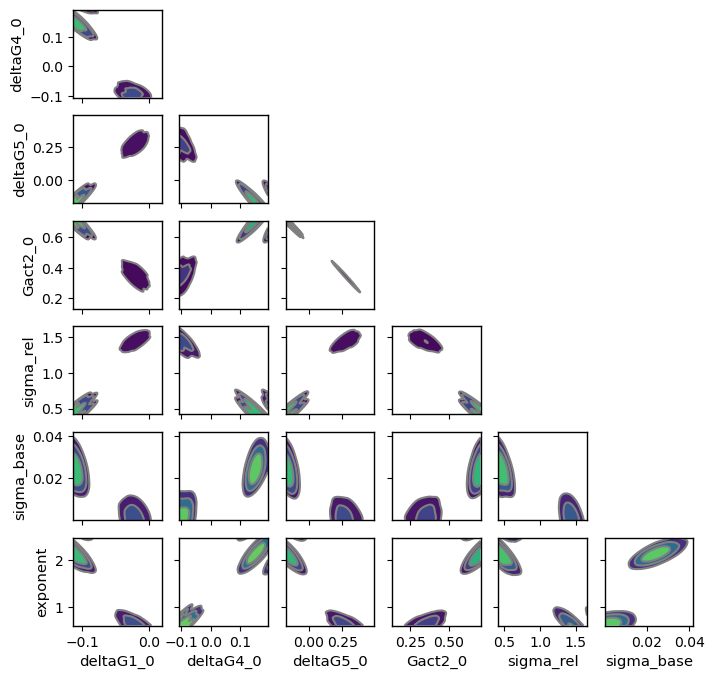

Sampling: [rate]


rate: 0.493


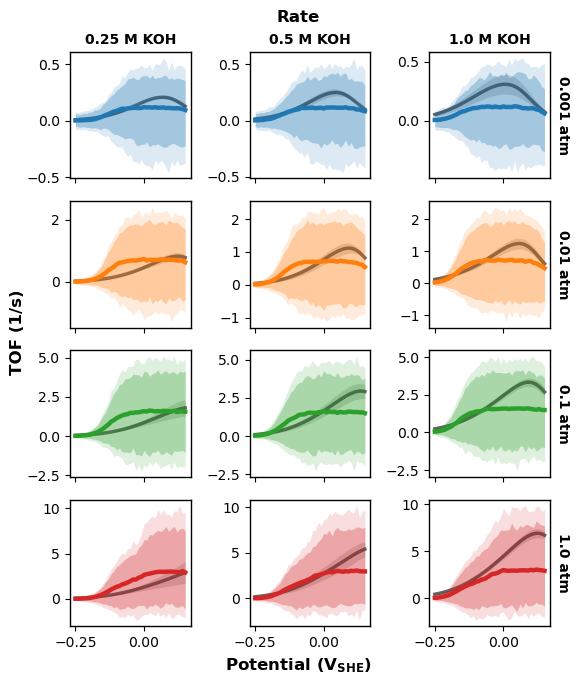

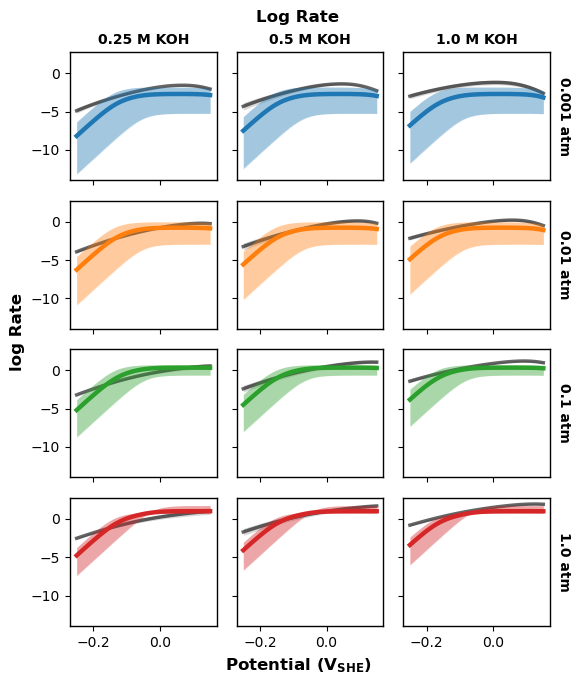

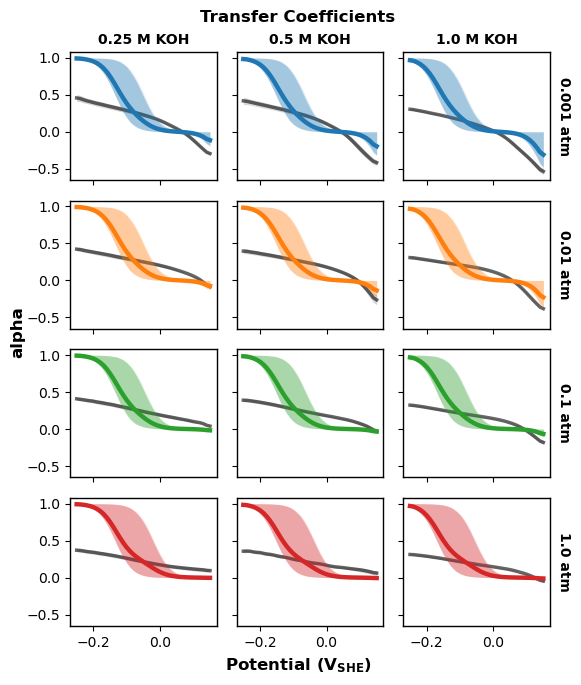

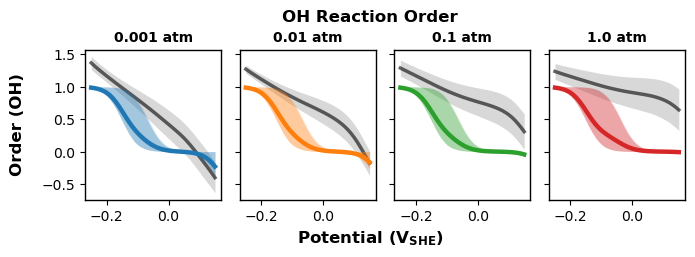

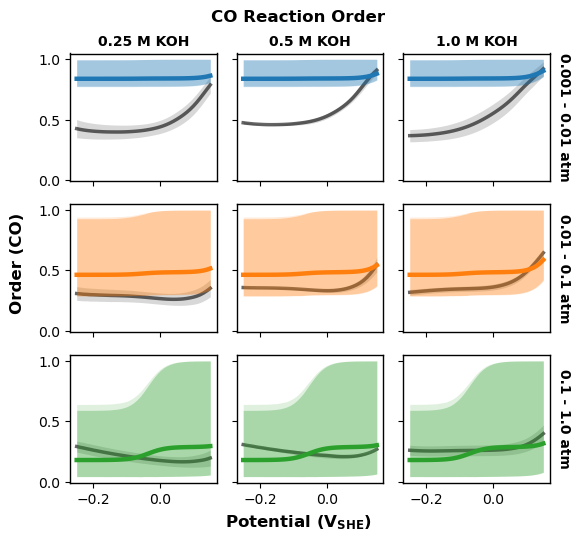

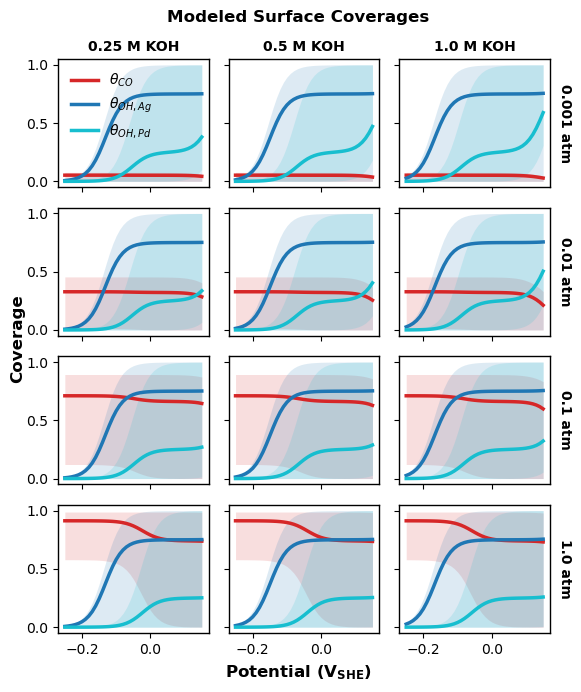

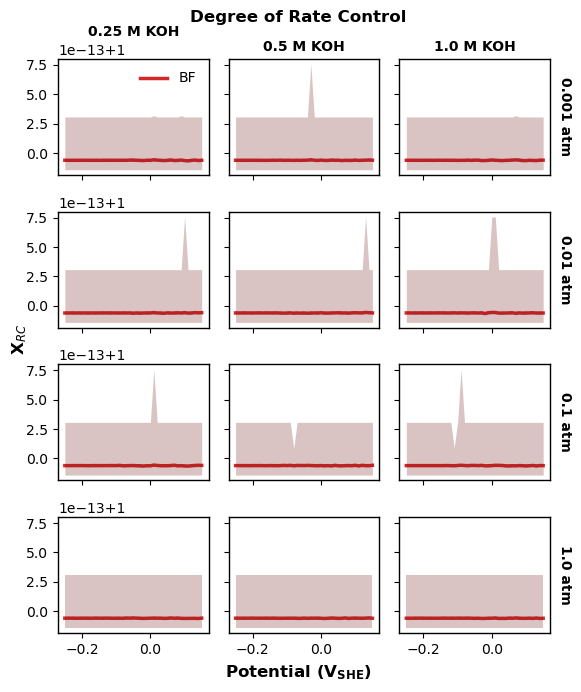

In [3]:
ppc_BF = plot_posteriors(trace_BF, BF)
plot_model_fits(trace_BF, ppc_BF); plot_coverages(trace_BF)
plot_drc(BF, trace_BF, perturb_vars=['Gact2_0'], perturb_labels=['BF'])

# ER 2 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.43,7
,3000,0,0.50,7
,3000,0,0.51,7
,3000,0,0.51,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   311.51    57.68
p_loo        7.76        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



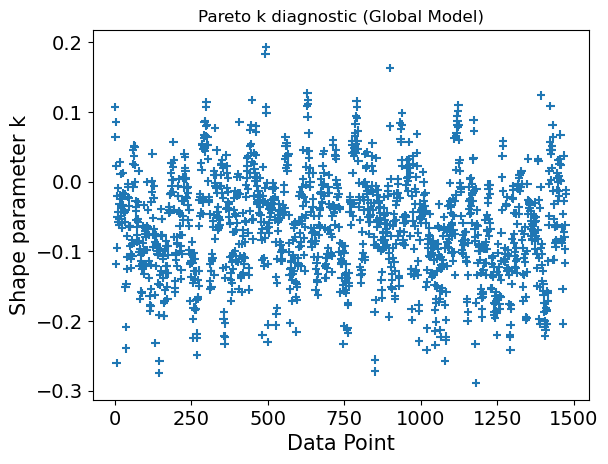

In [4]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.123  0.001  -0.125   -0.121      0.000    0.000    1778.0    2443.0    1.0
deltaG4_0   0.065  0.002   0.062    0.069      0.000    0.000    2163.0    2671.0    1.0
deltaG5_0   0.001  0.199  -0.369    0.371      0.003    0.003    5998.0    3022.0    1.0
Gact2_0     0.713  0.000   0.712    0.714      0.000    0.000    2670.0    2665.0    1.0
beta_2      0.227  0.003   0.221    0.232      0.000    0.000    2567.0    2806.0    1.0
sigma_rel   0.302  0.009   0.285    0.318      0.000    0.000    3547.0    2881.0    1.0
sigma_base  0.001  0.001   0.000    0.003      0.000    0.000    2642.0    1118.0    1.0
exponent    1.808  0.042   1.733    1.893      0.001    0.001    2407.0    2297.0    1.0


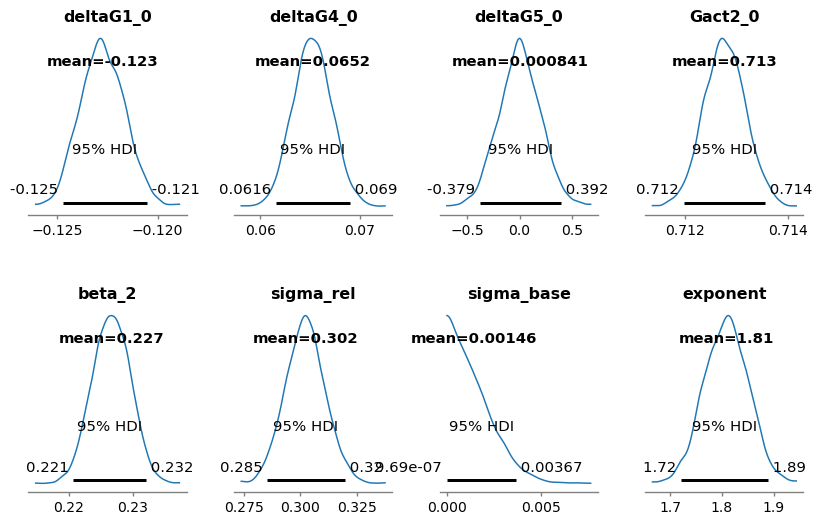

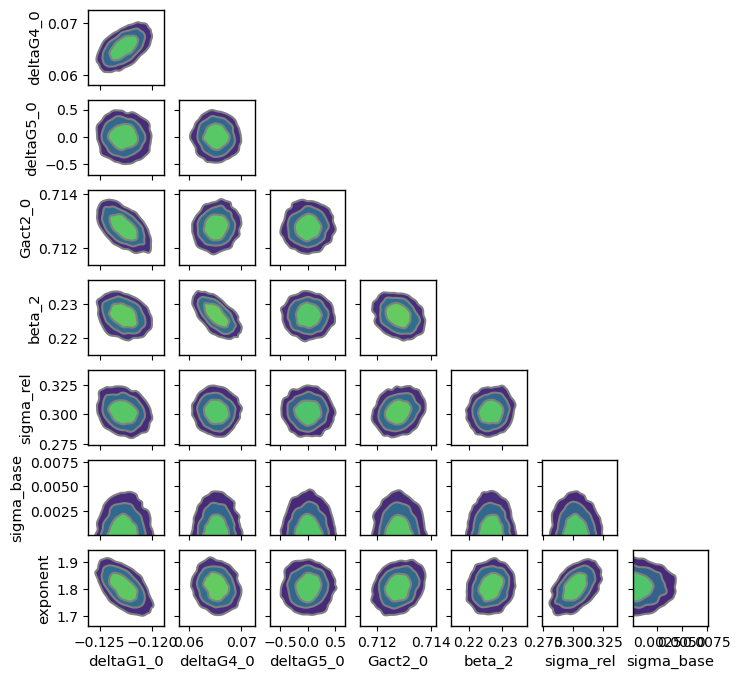

Sampling: [rate]


rate: 0.750


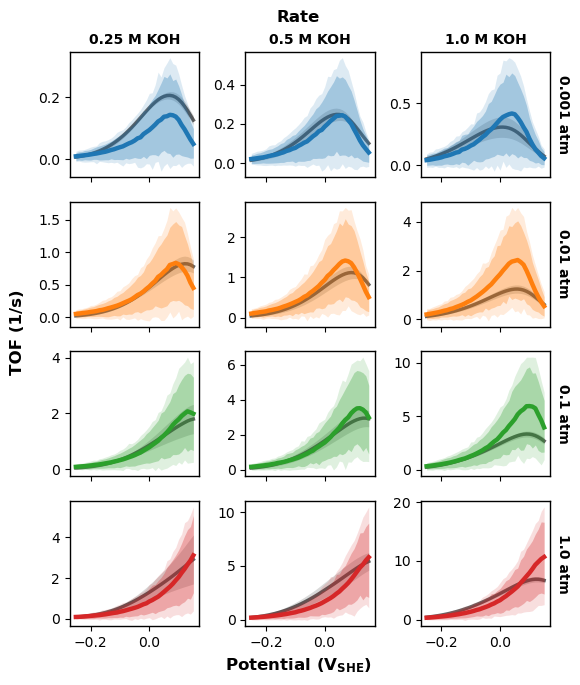

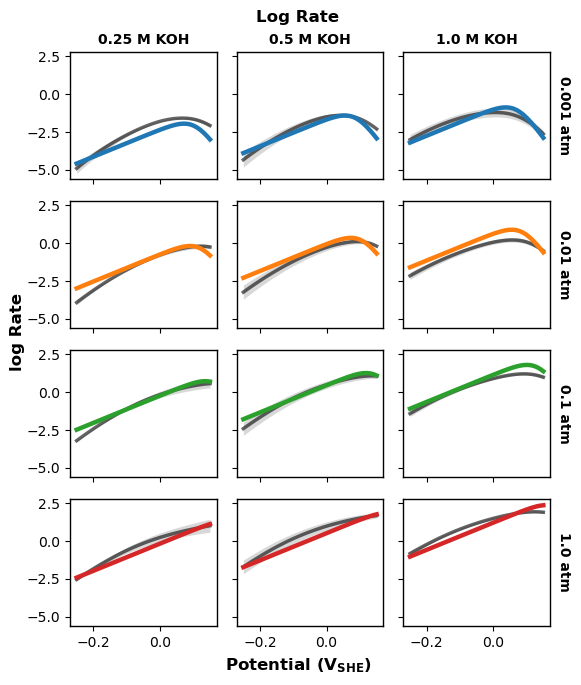

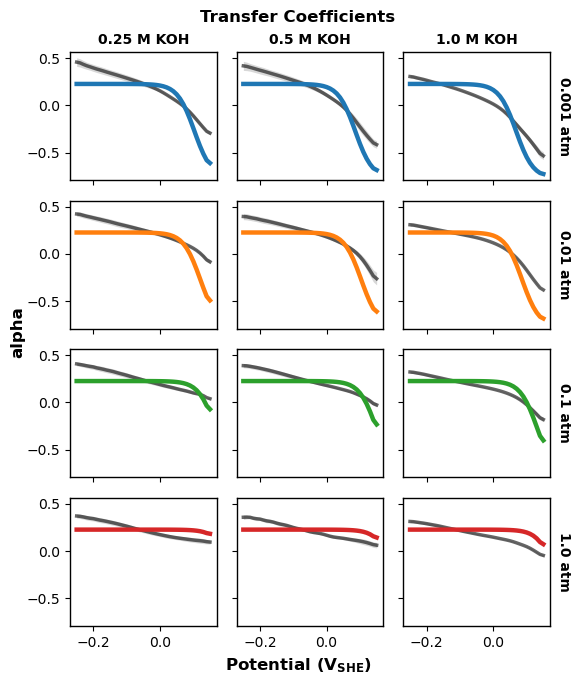

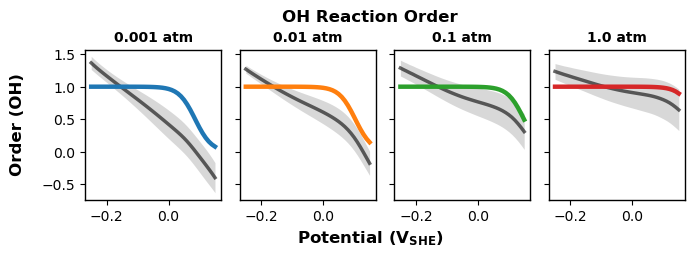

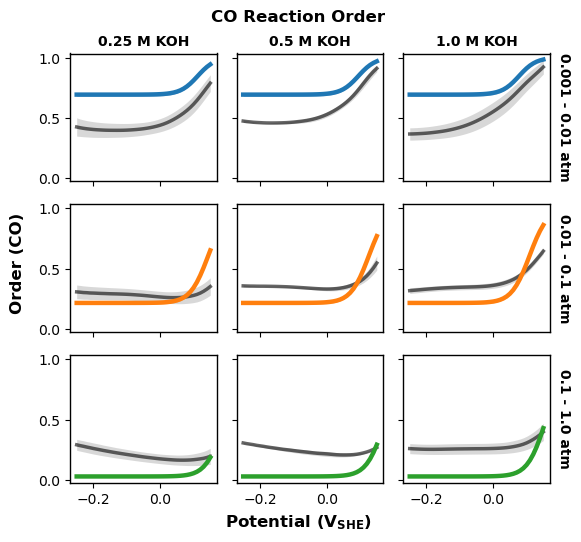

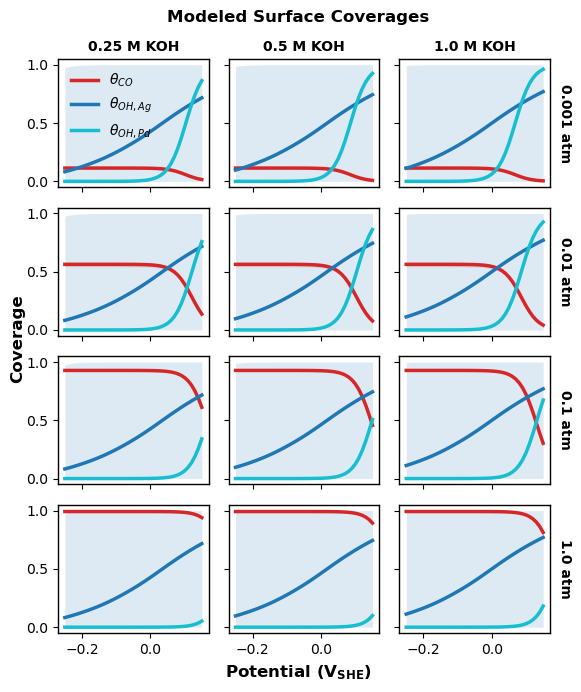

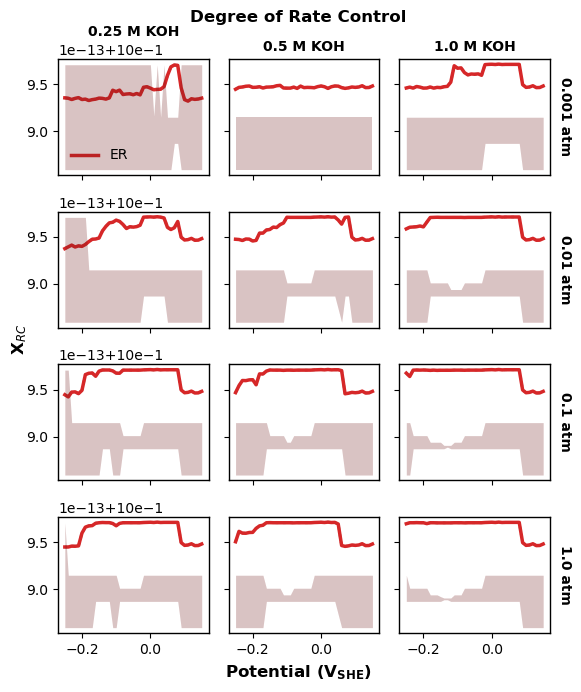

In [5]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)
plot_drc(ER_2, trace_ER_2, perturb_vars=['Gact2_0'], perturb_labels=['ER'])

# BF ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.38,31
,3000,0,0.36,15
,3000,0,0.41,15
,3000,0,0.39,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   441.29    57.39
p_loo       12.21        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



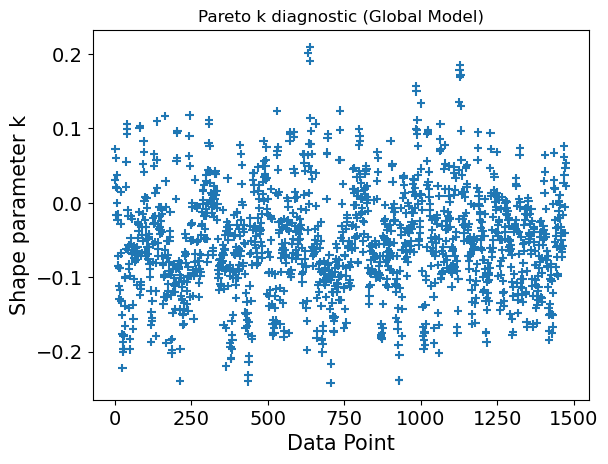

In [6]:
with pm.Model() as BF_ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_BF_ER_2, loo_BF_ER_2 = fit_and_evaluate(BF_ER_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.121  0.001  -0.123   -0.119      0.000    0.000    2320.0    2586.0    1.0
deltaG4_0   0.080  0.002   0.076    0.085      0.000    0.000    1933.0    2201.0    1.0
deltaG5_0  -0.123  0.006  -0.134   -0.112      0.000    0.000    2070.0    2389.0    1.0
Gact2_BF_0  0.741  0.002   0.737    0.746      0.000    0.000    1564.0    2195.0    1.0
Gact2_ER_0  0.721  0.001   0.719    0.722      0.000    0.000    1735.0    2320.0    1.0
beta_2      0.208  0.004   0.200    0.216      0.000    0.000    1673.0    2280.0    1.0
sigma_rel   0.283  0.008   0.269    0.299      0.000    0.000    3364.0    2579.0    1.0
sigma_base  0.001  0.001   0.000    0.004      0.000    0.000    2622.0    1300.0    1.0
exponent    1.843  0.047   1.756    1.930      0.001    0.001    2465.0    2452.0    1.0


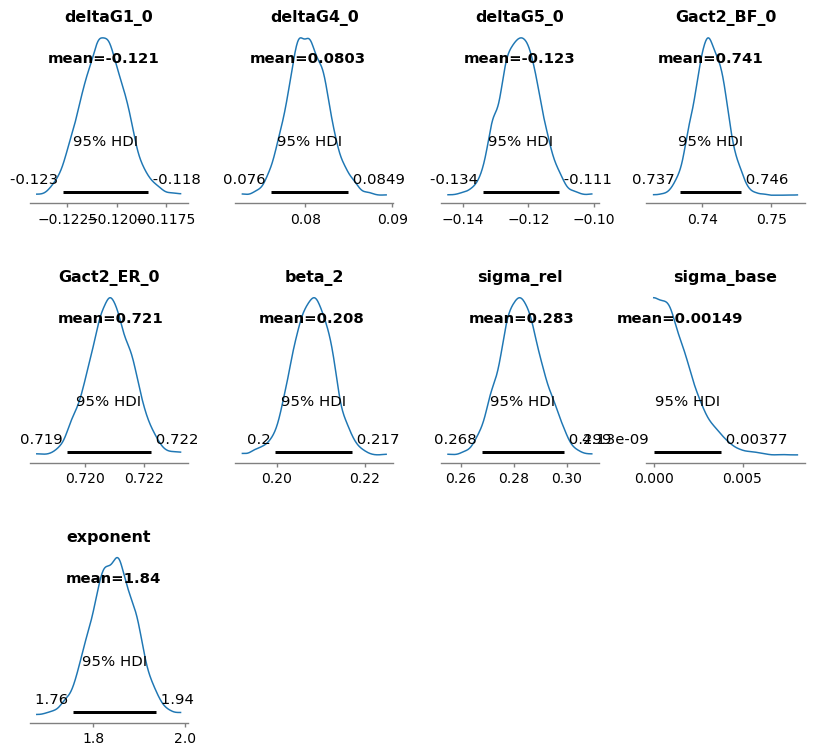

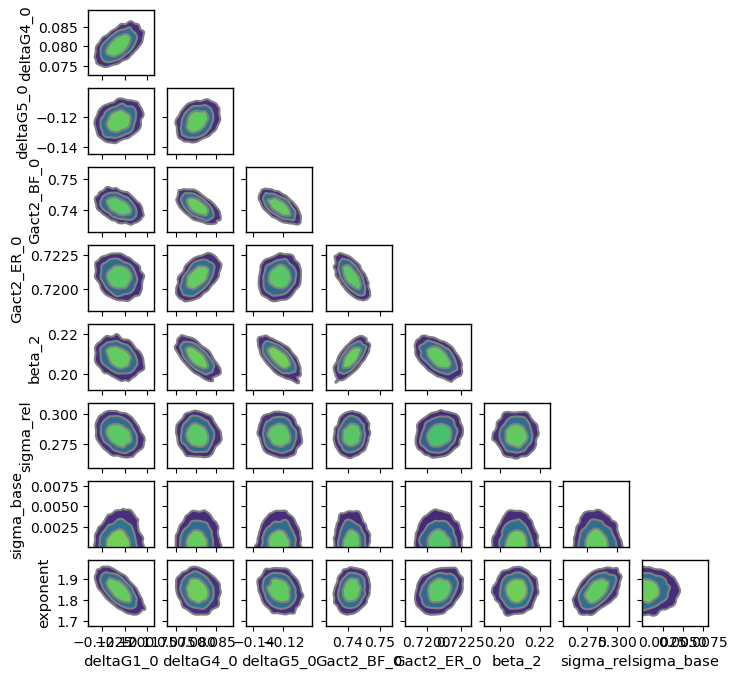

Sampling: [rate]


rate: 0.741


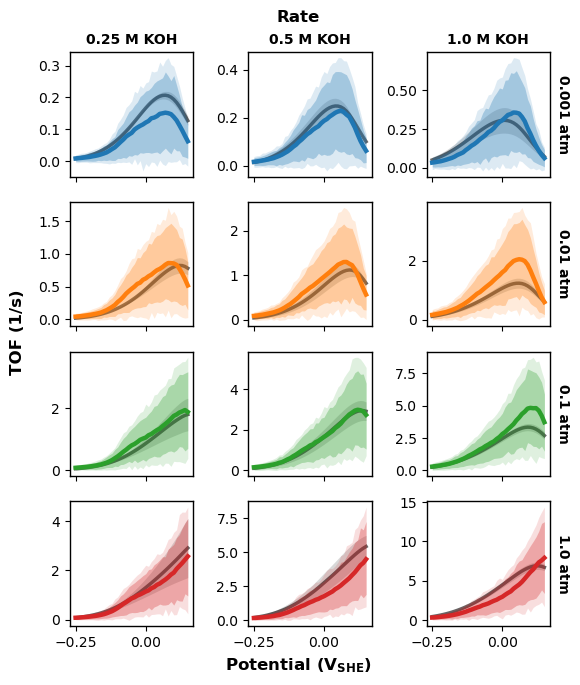

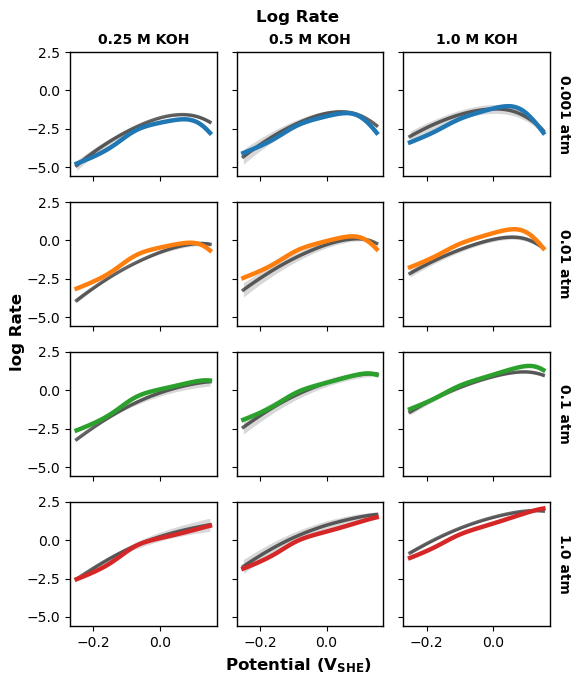

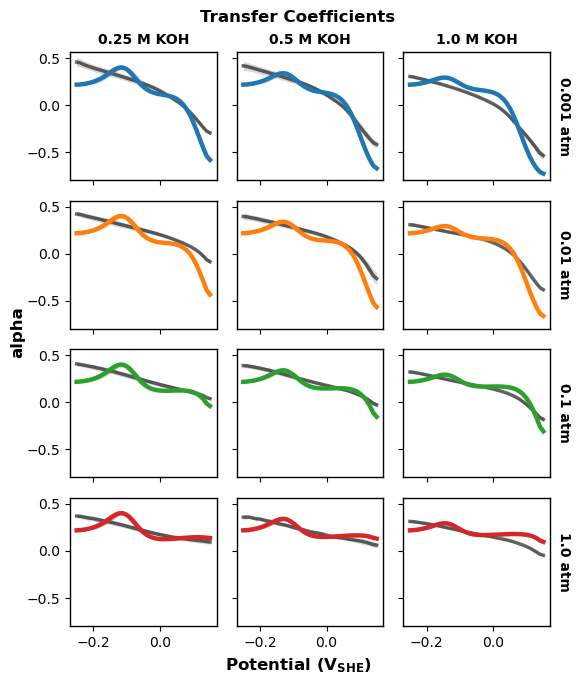

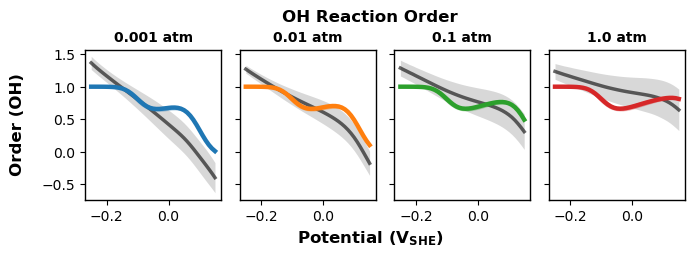

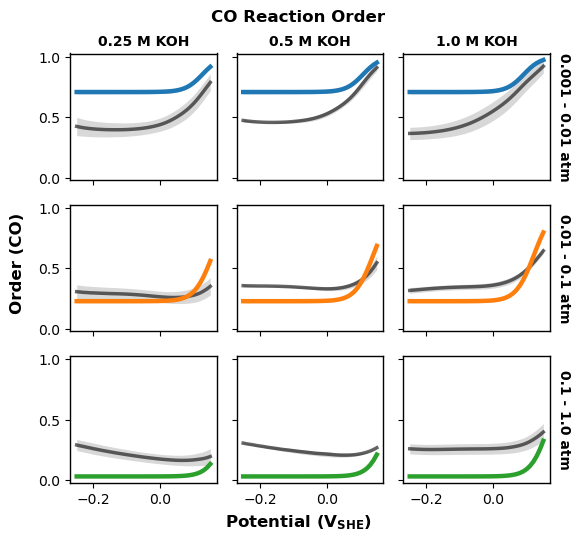

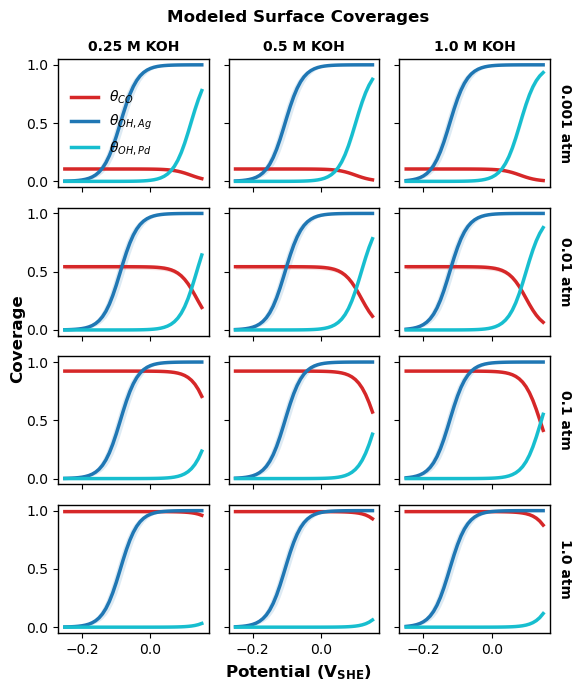

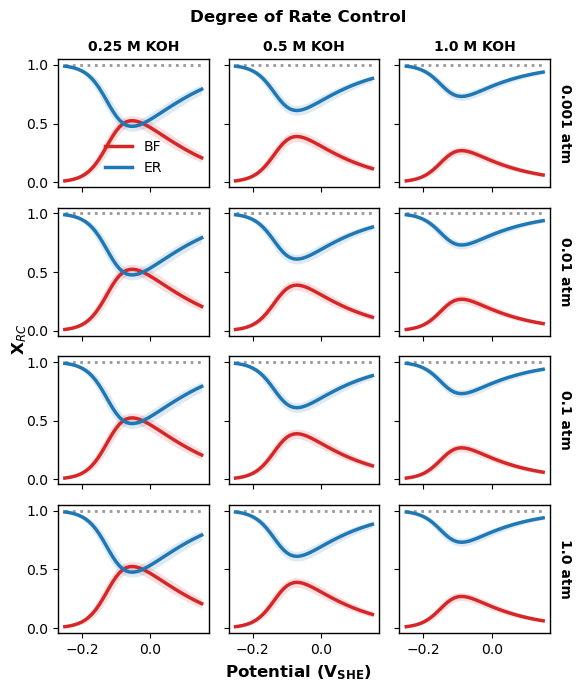

In [7]:
ppc_BF_ER_2 = plot_posteriors(trace_BF_ER_2, BF_ER_2)
plot_model_fits(trace_BF_ER_2, ppc_BF_ER_2); plot_coverages(trace_BF_ER_2)
plot_drc(BF_ER_2, trace_BF_ER_2, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0'], perturb_labels=['BF', 'ER'])

# BF ER LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.41,15
,3000,0,0.39,15
,3000,0,0.39,31
,3000,0,0.40,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   455.70    57.34
p_loo       12.56        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



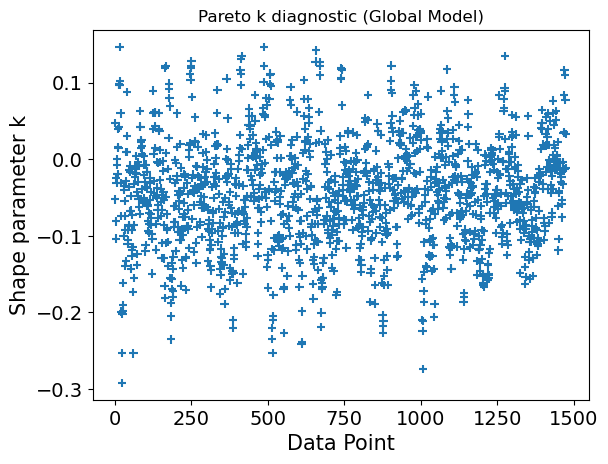

In [8]:
with pm.Model() as BF_ER_LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    2c. CO* + OH* -> COOH* + * (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    log_rate = pt.logsumexp(pt.stack([log_rate_BF, log_rate_ER, log_rate_LH]), axis=0)
    rate = observables(log_rate) 

trace_BF_ER_LH_2, loo_BF_ER_LH_2 = fit_and_evaluate(BF_ER_LH_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.120  0.001  -0.122   -0.118      0.000    0.000    2368.0    2283.0    1.0
deltaG4_0   0.073  0.002   0.069    0.077      0.000    0.000    2249.0    2665.0    1.0
deltaG5_0  -0.126  0.006  -0.137   -0.116      0.000    0.000    2762.0    2363.0    1.0
Gact2_BF_0  0.742  0.002   0.738    0.746      0.000    0.000    1822.0    2246.0    1.0
Gact2_ER_0  0.721  0.001   0.719    0.722      0.000    0.000    2197.0    2546.0    1.0
Gact2_LH_0  0.714  0.005   0.704    0.723      0.000    0.000    3501.0    2323.0    1.0
beta_2      0.207  0.004   0.199    0.214      0.000    0.000    2337.0    2702.0    1.0
sigma_rel   0.279  0.008   0.264    0.294      0.000    0.000    4131.0    3064.0    1.0
sigma_base  0.002  0.001   0.000    0.004      0.000    0.000    2544.0    1560.0    1.0
exponent    1.837  0.049   1.740    1.921      0.001    0.001    2870.0    3087.0    1.0


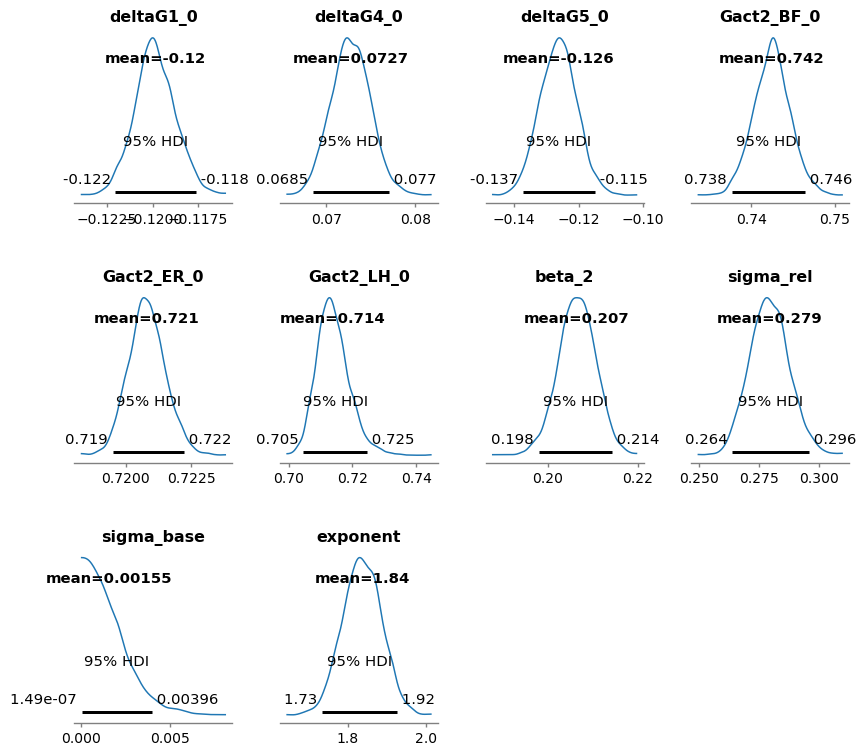

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


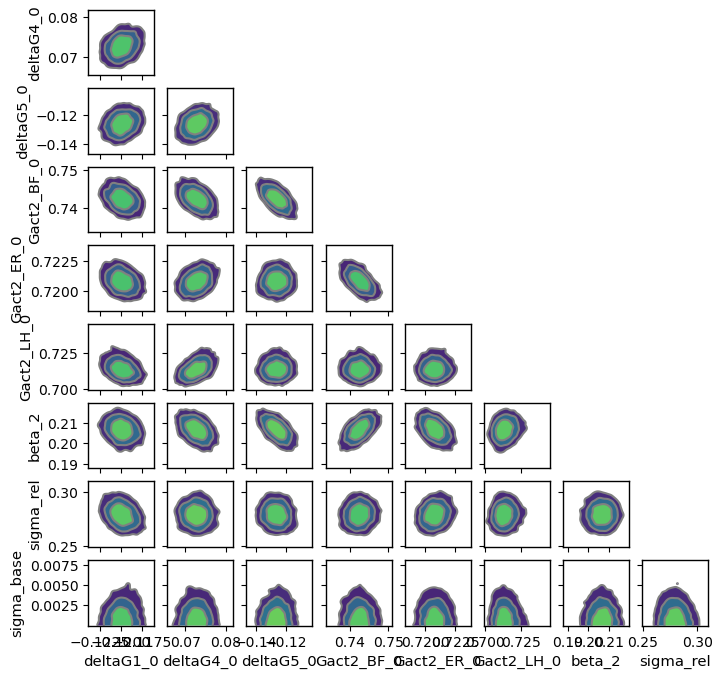

Sampling: [rate]


rate: 0.742


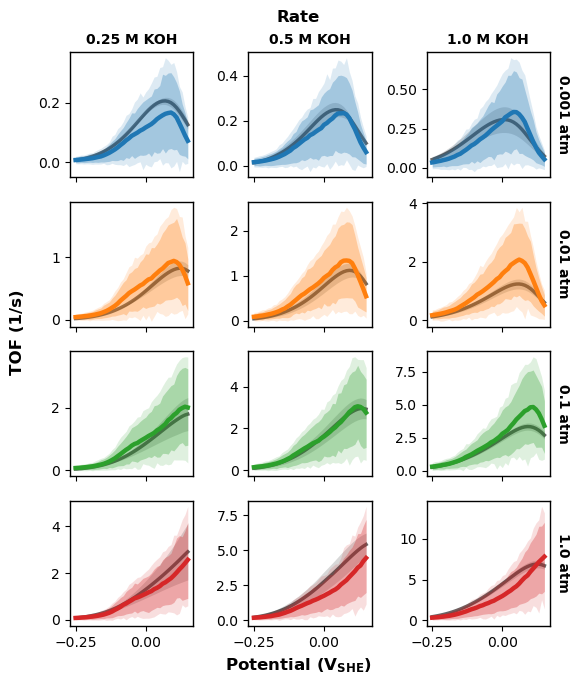

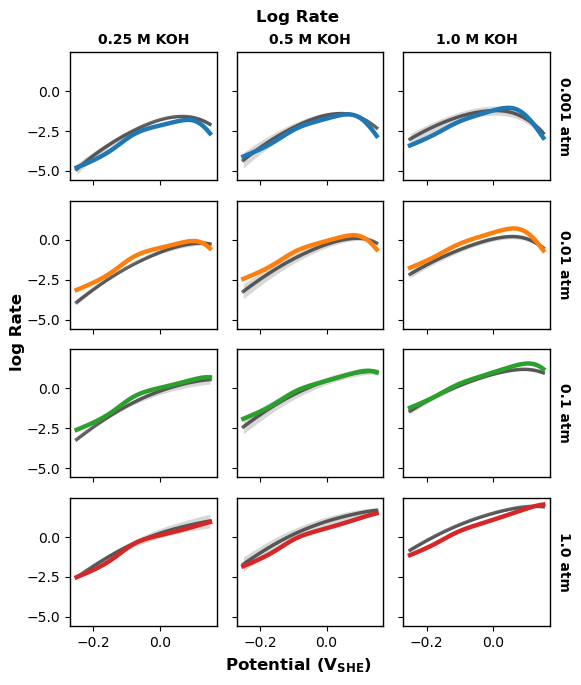

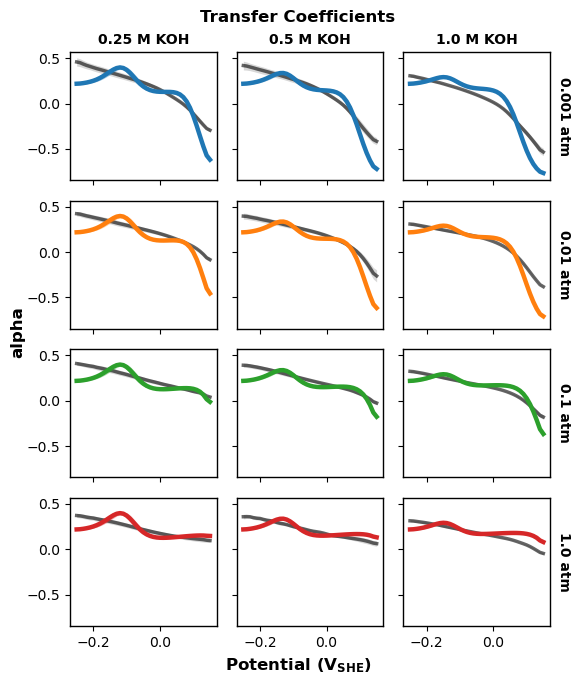

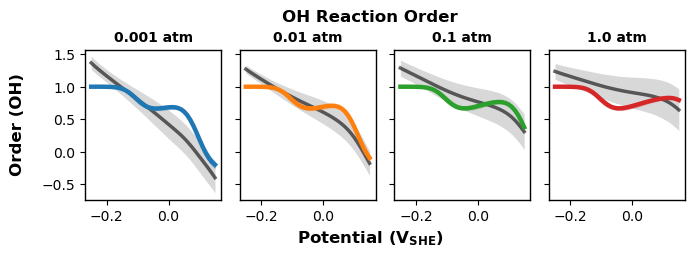

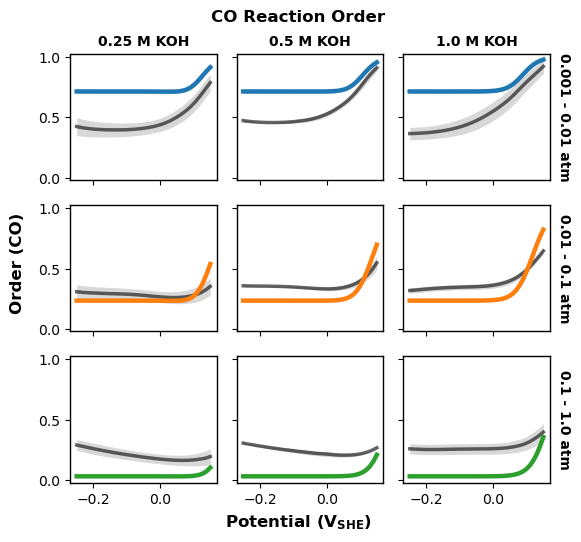

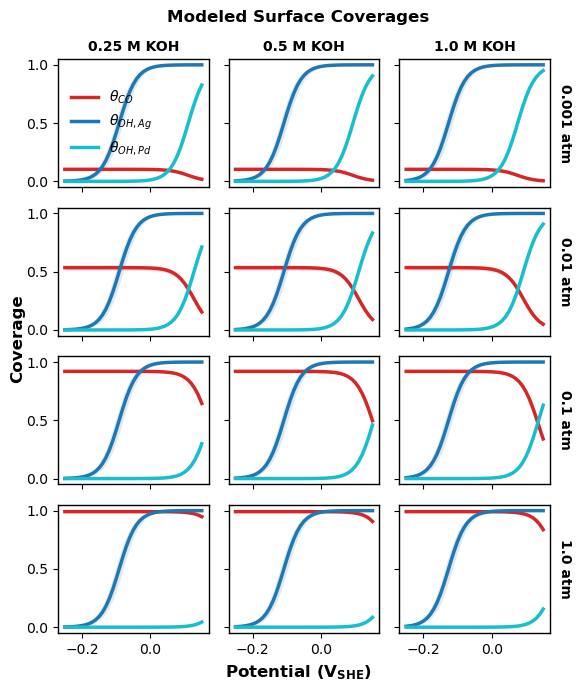

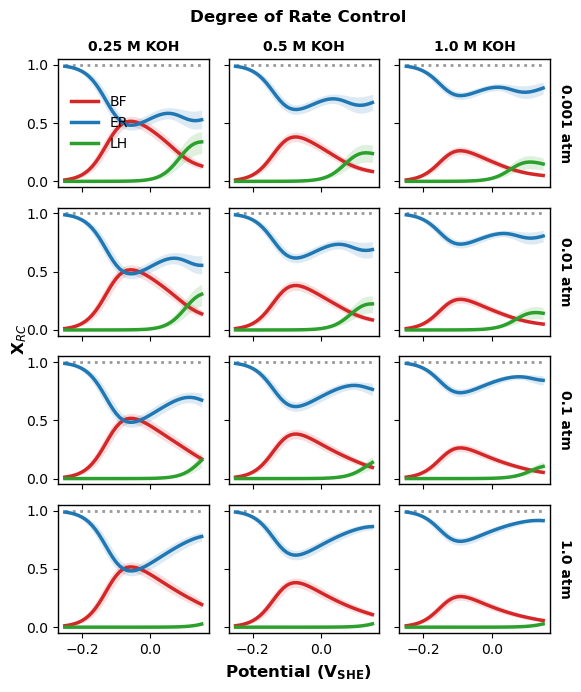

In [9]:
ppc_BF_ER_LH_2 = plot_posteriors(trace_BF_ER_LH_2, BF_ER_LH_2)
plot_model_fits(trace_BF_ER_LH_2, ppc_BF_ER_LH_2); plot_coverages(trace_BF_ER_LH_2)
plot_drc(BF_ER_LH_2, trace_BF_ER_LH_2, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0', 'Gact2_LH_0'], perturb_labels=['BF', 'ER', 'LH'])

# Comparison

            rank    elpd_loo       p_loo    elpd_diff        weight         se        dse  warning scale
BF_ER_LH_2     0  455.700807   12.563617     0.000000  8.895395e-01  57.340318   0.000000    False   log
BF_ER_2        1  441.285006   12.206416    14.415801  2.041669e-08  57.391519   3.928173    False   log
ER_2           2  311.511302    7.760611   144.189505  1.104604e-01  57.680141  19.483813    False   log
BF             3 -854.782625  361.936145  1310.483432  0.000000e+00  58.044048  34.452927     True   log


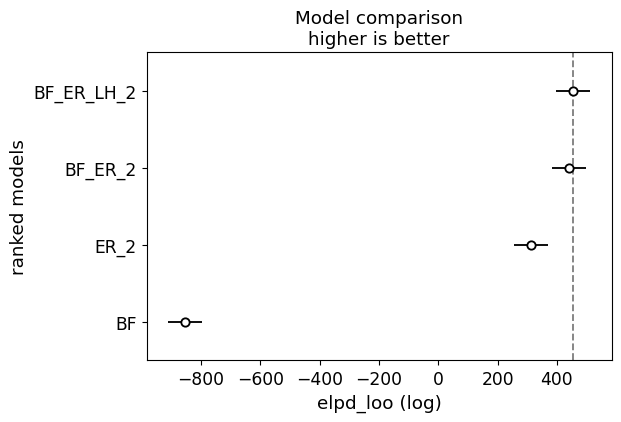

In [10]:
comparison_dict = {
    "BF": loo_BF,
    "ER_2": loo_ER_2,
    "BF_ER_2": loo_BF_ER_2,
    "BF_ER_LH_2": loo_BF_ER_LH_2
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()